## Sampling Klein filters

A Gabor filter is a function on $[-1,1]^2$

The Klein subset of Gabor filters is given by (see formula (9), and later formulae page 15, of [`Topological Convolutional Layers for Deep Learning`](https://www.jmlr.org/papers/volume24/21-0073/21-0073.pdf#page=15)) 

$$\tilde{g}(\theta_1, \theta_2) = -\cos\left(\frac{\pi\cdot x'(\theta_1)}{1+2\theta_2/\pi}+\theta_2\right)$$

where 

$$x'(\omega)=x\cos(\omega)+y\sin(\omega)$$

**Note** that $\tilde{g}(\theta_1, \theta_2)$ is $2\pi$-periodic in $\theta_1$, but **not exactly** $2\pi$-periodic in $\theta_2$!

In [2]:
import numpy as np

import matplotlib.pyplot as plt

In [3]:
class GK:
    """
    Gabor-Klein filter
    """
    def __init__(self, theta1, theta2):
        self.th1 = theta1
        self.th2 = theta2
        
    def f(self,xs,ys):
        """
        Input: xs, ys - 2d meshgrids
        built from linspace(-1,1,n_points)
        """
        x_prime = xs*np.cos(self.th1)+ys*np.sin(self.th1)
        frac = np.pi*x_prime
        frac /= (1+2*self.th2/np.pi)
        return -1*np.cos(frac + self.th2)

In [4]:
n_points = 5

xs = np.linspace(-1, 1, n_points)
ys = np.linspace(-1, 1, n_points)

xv, yv = np.meshgrid(xs, ys)

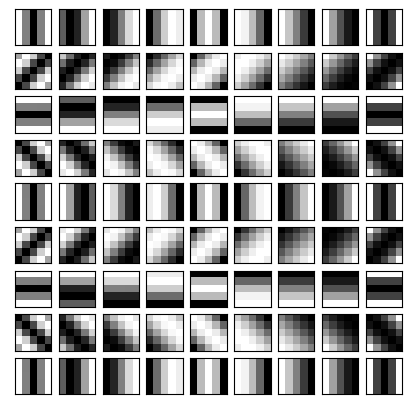

In [5]:
n = 8

fig = plt.figure(figsize=(5,5))
ax = fig.subplots(n+1,n+1)

for i in range(0,n+1):
    for j in range(0,n+1):
        
        ax[i,j].imshow(GK((2*np.pi/8)*i,(2*np.pi/8)*j).f(xv,yv), 
                        cmap='gray')
        ax[i,j].axes.get_xaxis().set_ticks([])
        ax[i,j].axes.get_yaxis().set_ticks([])
        
        # for showing indices
        #ax[i,j].set_title(f'{i},{j}')
        
# i - theta1 - 2pi-periodic
# j - theta2 - ALMOST 2pi-periodic

#fig.supylabel('θ₁ from 0 to 2pi')
#fig.supxlabel('θ₂ from 0 to 2pi')

#fig.savefig('Klein-Gabor-filters.png', dpi=300, transparent=True)

plt.show()

## Checking persistent homology (PH)

One can see that the filters for 

- $\theta_1$ varying from $0$ to $\approx\!\pi$ (**not** $2\pi$ !)
- $\theta_2$ varying from $0$ to $2\pi$

– form a Klein bottle

In [6]:
from ripser import ripser

In [7]:
from persim import plot_diagrams

In [8]:
n_angles = 1_000

th1s = np.random.uniform(0, 2*np.pi, n_angles)
th2s = np.random.uniform(0, 2*np.pi, n_angles)

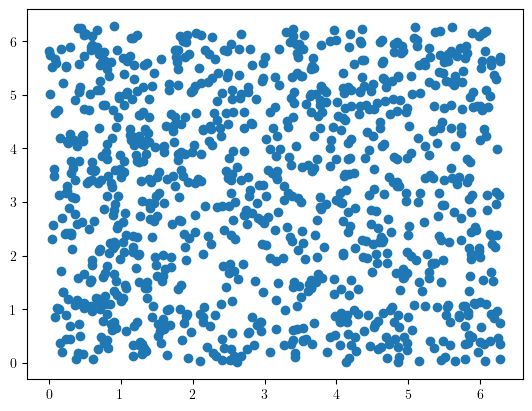

In [9]:
plt.scatter(th1s, th2s)

In [10]:
n_points = 5
xs = np.linspace(-1, 1, n_points)
ys = np.linspace(-1, 1, n_points)
xv, yv = np.meshgrid(xs, ys)

filters = []

for i in range(n_angles):
    filter_ = GK(th1s[i],th2s[i]).f(xv,yv)
    filters.append(filter_.flatten())
    
filters = np.array(filters)

In [11]:
filters.shape

(1000, 25)

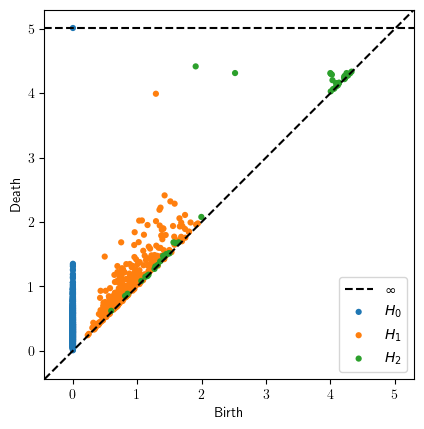

In [12]:
# Homology over Z_2
diagrams2 = ripser(filters, coeff=2, maxdim=2)['dgms']

plot_diagrams(diagrams2)

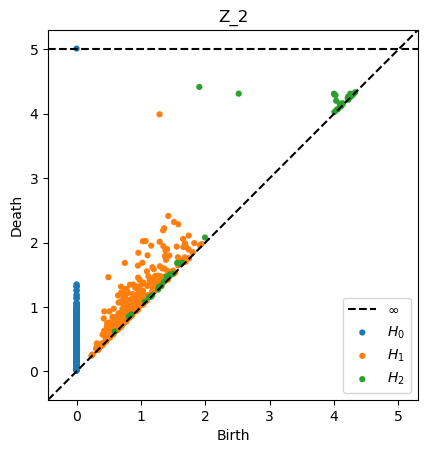

In [13]:
plt.title('Z_2')
plot_diagrams(diagrams2)

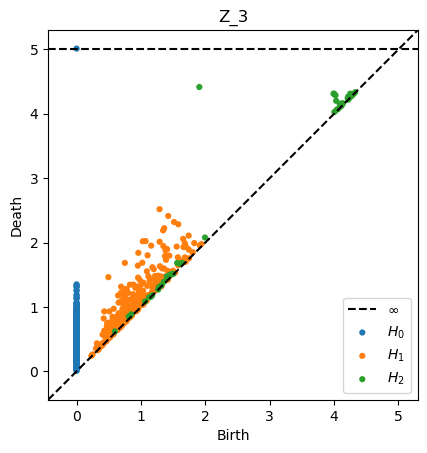

In [14]:
# Homology over Z_3
diagrams3 = ripser(filters, coeff=3, maxdim=2)['dgms']

plt.title('Z_3')
plot_diagrams(diagrams3)